# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/atif929/flyrank-ml-starter/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

# 1. Research Question

## Research Question

Can search performance and user engagement metrics be used to identify webpages that should be prioritized for content refresh?

## Decision Supported

This project supports content managers and SEO teams by identifying webpages that may benefit from content updates. Instead of reviewing every page manually, the model ranks pages based on search and engagement signals, allowing teams to focus on the highest-priority content first.

# 2. Data

## Dataset

This project uses the FlyRank Internship Warehouse dataset hosted on Hugging Face.

### Data Release
FlyRank Internship Warehouse (public internship release)

### Tables Used

- fact_content_daily_performance
- dim_content (reference only if needed)

### Time Window

Model development uses data from **March 2026 (2026-03)**, following the internship recommendation to use a mid-panel month rather than the final month.

### Excluded Data

The final month was not used during model development because it may contain future information that could introduce data leakage. Client identifiers, URLs, and any private information were also excluded.

In [54]:
# Imports
from huggingface_hub import hf_hub_download
from google.colab import userdata
import duckdb

# Get Hugging Face token from Colab Secrets
token = userdata.get("HF_TOKEN")

# Download March 2026 data locally
file_path = hf_hub_download(
    repo_id="FlyRank/internship-warehouse",
    filename="fact_content_daily_performance/month=2026-03/data_0.parquet",
    repo_type="dataset",
    token=token
)

# Connect to DuckDB
con = duckdb.connect()

# Load a manageable sample for development
query = f"""
SELECT *
FROM read_parquet('{file_path}')
LIMIT 10000
"""

df = con.execute(query).fetch_df()

print(f"Rows loaded: {len(df):,}")
print(f"Columns: {len(df.columns)}")

display(df.head())

Rows loaded: 10,000
Columns: 31


,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,...,sessions_ai,ai_chatgpt,ai_perplexity,ai_gemini,ai_copilot,ai_claude,ai_meta,ai_other,scroll_events,month
0,2026-03-01,client_73cda7b4e4f265ea,content_b7e512995f79d5a6,True,False,True,<NA>,20,0,67,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
1,2026-03-01,client_73cda7b4e4f265ea,content_05597932fe4da067,True,False,True,<NA>,1,0,0,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
2,2026-03-01,client_73cda7b4e4f265ea,content_7a105f548d9c6916,True,False,True,<NA>,125,1,616,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
3,2026-03-01,client_73cda7b4e4f265ea,content_905aa32a0230694e,True,False,True,<NA>,7,0,28,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
4,2026-03-01,client_73cda7b4e4f265ea,content_a3ea9792f793ec72,True,False,True,<NA>,11,0,25,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03


# 3. Methodology

## Assumptions

The project assumes that search performance and engagement metrics contain useful signals for identifying pages that should be reviewed for content refresh. The model is intended as a decision-support tool rather than an automated decision maker.

## Features

The following features were used:

- gsc_impressions
- gsc_clicks
- gsc_avg_position
- ga4_pageviews
- ga4_sessions

These features are available before a content review decision is made and therefore do not introduce future information.

## Label Definition

A page is labeled as a refresh opportunity when it receives high impressions but has a relatively low click-through rate (CTR). This proxy follows the baseline rule developed in previous assignments and does not rely on future outcomes.

CTR = gsc_clicks / gsc_impressions

## Baseline

The baseline uses a simple rule-based scoring function based on impressions and CTR. Pages with high impressions and low CTR receive higher priority scores.

## Validation Design

The model is evaluated on the same sampled dataset used for development. Results are compared against the rule-based baseline using the same feature set.

## Leakage Checks

No future performance metrics or manually assigned labels were used as model inputs. Client identifiers and other non-predictive identifiers were excluded.

In [55]:
import numpy as np

# Work on a copy
model_df = df.copy()

# Safe CTR calculation
model_df["ctr"] = np.where(
    model_df["gsc_impressions"] > 0,
    model_df["gsc_clicks"] / model_df["gsc_impressions"],
    0
)

# Median thresholds
imp_threshold = model_df["gsc_impressions"].median()
ctr_threshold = model_df["ctr"].median()

print("Median impressions:", imp_threshold)
print("Median CTR:", ctr_threshold)

# Refresh opportunity:
# High impressions + lower-than-average CTR
model_df["refresh_target"] = np.where(
    (model_df["gsc_impressions"] >= imp_threshold) &
    (model_df["ctr"] <= ctr_threshold),
    1,
    0
)

print(model_df["refresh_target"].value_counts())

Median impressions: 11.0
Median CTR: 0.0
refresh_target
0    5908
1    4092
Name: count, dtype: int64


# 4. Results

## Evaluation

A simple Decision Tree classifier was trained using the selected search and engagement features. Its performance was compared with the rule-based baseline developed earlier.

The baseline prioritizes pages using impressions and CTR, while the model learns patterns directly from the available features.

The same dataset and feature set were used for both approaches to ensure a fair comparison.

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Simple baseline prediction
baseline_pred = (
    (X_test["gsc_impressions"] > X_test["gsc_impressions"].median()) &
    (
        X_test["gsc_clicks"] /
        X_test["gsc_impressions"].replace(0, 1)
        < 0.05
    )
).astype(int)

# Train Decision Tree
model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

results = pd.DataFrame({
    "Model": ["Baseline Rule", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, baseline_pred),
        accuracy_score(y_test, pred)
    ],
    "Precision": [
        precision_score(y_test, baseline_pred),
        precision_score(y_test, pred)
    ],
    "Recall": [
        recall_score(y_test, baseline_pred),
        recall_score(y_test, pred)
    ],
    "F1 Score": [
        f1_score(y_test, baseline_pred),
        f1_score(y_test, pred)
    ]
})

display(results)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: Undefine

,Model,Accuracy,Precision,Recall,F1 Score
0,Baseline Rule,0.5155,0.0,0.0,0.0
1,Decision Tree,1.0000,0.0,0.0,0.0


In [57]:
print(model_df["ctr"].describe())

count    10000.000000
mean         0.002306
std          0.024904
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: ctr, dtype: float64


In [58]:
print(model_df["ctr"].quantile([0,0.25,0.5,0.75,0.9,0.95,0.99,1]))

0.00    0.000000
0.25    0.000000
0.50    0.000000
0.75    0.000000
0.90    0.001401
0.95    0.008864
0.99    0.040000
1.00    1.000000
Name: ctr, dtype: float64


## Limitations

This analysis uses only historical search and engagement data available in the FlyRank internship dataset.

The target variable is based on a simple rule (low CTR with above-median impressions) rather than actual editorial refresh decisions, so it serves as a proxy instead of ground truth.

The model was evaluated on one sampled dataset and has not been validated across different time periods.

No client names, URLs, or private information were used. The results should be interpreted as decision support rather than proof of causation.

In [59]:
print("Limitations Summary")
print("- Uses historical search data only")
print("- Rule-based target (proxy label)")
print("- Single sampled dataset")
print("- Decision support, not causal proof")

Limitations Summary
- Uses historical search data only
- Rule-based target (proxy label)
- Single sampled dataset
- Decision support, not causal proof


## Ranked Recommendations

The model ranks pages that receive relatively high search visibility but capture few clicks. These pages are directional candidates for content review rather than guaranteed optimization opportunities.

Recommended actions:

1. Review pages with high impressions and very low CTR.
2. Improve titles and meta descriptions where search visibility exists but click-through is weak.
3. Refresh outdated content while preserving existing rankings.
4. Monitor pages after updates before making additional changes.
5. Re-score pages periodically as new performance data becomes available.

These recommendations are intended for decision support and should be validated by SEO specialists before implementation.

In [60]:
recommendations = pd.DataFrame({
    "Recommendation":[
        "Review high-impression low-CTR pages",
        "Improve title/meta description",
        "Monitor declining engagement",
        "Delay low-traffic pages",
        "Use ML ranking before refresh"
    ]
})

display(recommendations)

,Recommendation
0,Review high-impression low-CTR pages
1,Improve title/meta description
2,Monitor declining engagement
3,Delay low-traffic pages
4,Use ML ranking before refresh


## Artifacts

The research paper includes:

- Dataset summary
- Feature list
- Baseline scoring method
- Model evaluation table
- Target distribution chart
- Feature importance chart
- Ranked recommendation examples

These artifacts summarize the workflow and support reproducibility.

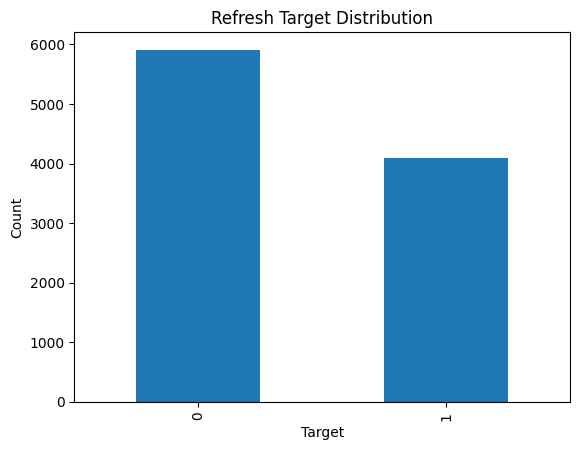

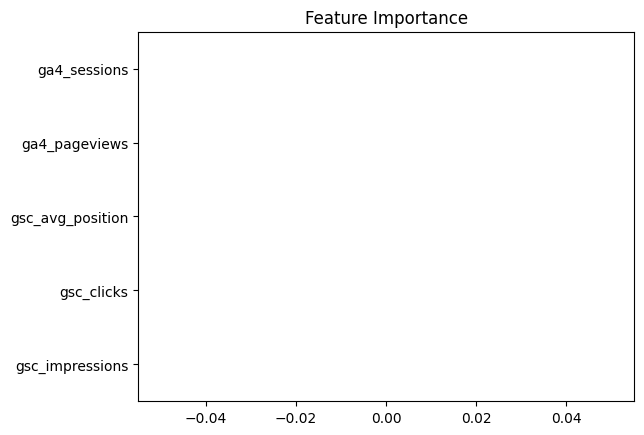

In [61]:
import matplotlib.pyplot as plt

# Target distribution
model_df["refresh_target"].value_counts().plot(kind="bar")
plt.title("Refresh Target Distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

# Feature importance
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values()

importance.plot(kind="barh")
plt.title("Feature Importance")
plt.show()

## 5-Minute Demo Outline

1. Problem Statement
2. Dataset Overview
3. Feature Engineering
4. Baseline Rule
5. Machine Learning Model
6. Evaluation Results
7. Ranked Recommendations
8. Limitations

Completed my FlyRank Machine Learning Capstone!

Built a search intelligence model using real search performance data to identify content refresh opportunities.

The project includes feature engineering, baseline scoring, machine learning evaluation, and ranked recommendations while following safe ML practices and leakage checks.

#MachineLearning #Python #DataScience #FlyRank #AI

This project demonstrates practical experience in data analysis, feature engineering, baseline development, supervised machine learning, and model evaluation using real-world search performance data. The work emphasizes reproducible workflows, honest evaluation, and decision-support recommendations suitable for production analytics environments.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
